# Dengue notifications in Brazil and Rio de Janeiro
## A presentation-ready DATASUS/SINAN workflow

**Purpose.** Describe the official weekly dengue-notification patterns in Brazil and Rio de Janeiro, then show how same-period Google Trends and Portuguese Wikipedia attention signals were evaluated as retrospective 2025 nowcasts.

**Structure.** Part I stays with the downloaded DATASUS/SINAN outcome series. Part II adds the archived online-attention signals and model outputs already produced in this workspace. Notification records are the outcome; Trends and Wikipedia are predictors.

## Presentation flow

1. State the surveillance question and define the outcome.
2. Load the four archived DATASUS/SINAN weekly series.
3. Check dates, duplicates, and the incomplete boundary weeks.
4. Compare Brazil and Rio in 2024, when the large epidemic wave is visible.
5. Compare the 2024 and 2025 seasonal patterns within each geography.
6. Close with descriptive takeaways and limits of interpretation.

> **Key definition:** each value is the number of dengue notification records with symptom onset in a Sunday–Saturday week. These are notified records, not a final confirmed-case count.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
RIO_DIR = ROOT / 'rj_trends'
BRAZIL_DIR = ROOT / 'wikipedia'

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'Brazil': '#2563a8', 'Rio de Janeiro': '#b22222', '2024': '#b22222', '2025': '#16803c'}

## Step 1 — Load the official case series

The national files are saved in `wikipedia/` because they were prepared alongside a separate pageview exercise; here we use only their `date` and `sinan_notified_cases` columns. The Rio files contain records for Rio de Janeiro residents.

In [2]:
def load_weekly(path, geography, year):
    data = pd.read_csv(path, parse_dates=['date'])[['date', 'sinan_notified_cases']].copy()
    data['geography'] = geography
    data['year'] = year
    return data

brazil_2024 = load_weekly(BRAZIL_DIR / 'brazil_sinan_dengue_2024_weekly.csv', 'Brazil', 2024)
brazil_2025 = load_weekly(BRAZIL_DIR / 'brazil_sinan_dengue_2025_weekly.csv', 'Brazil', 2025)
rio_2024 = load_weekly(RIO_DIR / 'rio_dengue_trends_vs_sinan_2024_weekly.csv', 'Rio de Janeiro', 2024)
rio_2025 = load_weekly(RIO_DIR / 'rio_dengue_sinan_2025_weekly.csv', 'Rio de Janeiro', 2025)

weekly = pd.concat([brazil_2024, brazil_2025, rio_2024, rio_2025], ignore_index=True)
weekly.head()

,date,sinan_notified_cases,geography,year
0,2023-12-31,45848,Brazil,2024
1,2024-01-07,61515,Brazil,2024
2,2024-01-14,89814,Brazil,2024
3,2024-01-21,127227,Brazil,2024
4,2024-01-28,164645,Brazil,2024


## Step 2 — Validate what will be presented

Before plotting, confirm that there is one weekly value per geography/year, that case counts are non-negative, and identify the endpoint caveat. The final week beginning **2025-12-28** crosses into 2026, so it is omitted from year-to-year comparisons. The 2024 file also includes a zero-valued week beginning 2024-12-29; the overlapping 2025 extract provides the usable count for that week.

In [3]:
quality_check = (weekly.groupby(['geography', 'year'])
                 .agg(weeks=('date', 'size'),
                      first_week=('date', 'min'),
                      last_week=('date', 'max'),
                      duplicate_weeks=('date', lambda x: x.duplicated().sum()),
                      negative_counts=('sinan_notified_cases', lambda x: (x < 0).sum()))
                 .reset_index())
display(quality_check)

assert quality_check['duplicate_weeks'].eq(0).all()
assert quality_check['negative_counts'].eq(0).all()
analysis = weekly.loc[weekly['date'].ne(pd.Timestamp('2025-12-28'))].copy()
analysis = analysis.loc[~((analysis['year'].eq(2024)) & (analysis['date'].eq(pd.Timestamp('2024-12-29'))))].copy()
print(f'Presentation analysis set: {len(analysis):,} weekly geography-year observations.')

,geography,year,weeks,first_week,last_week,duplicate_weeks,negative_counts
0,Brazil,2024,53,2023-12-31,2024-12-29,0,0
1,Brazil,2025,53,2024-12-29,2025-12-28,0,0
2,Rio de Janeiro,2024,53,2023-12-31,2024-12-29,0,0
3,Rio de Janeiro,2025,53,2024-12-29,2025-12-28,0,0


Presentation analysis set: 208 weekly geography-year observations.


## Step 3 — Establish the 2024 epidemic context

Start with 2024 because it makes the shared seasonal shape most visible. Brazil and Rio have very different population sizes, so this is a **timing comparison**, not a comparison of burden per resident. Each line is scaled to its own 2024 peak (=100).

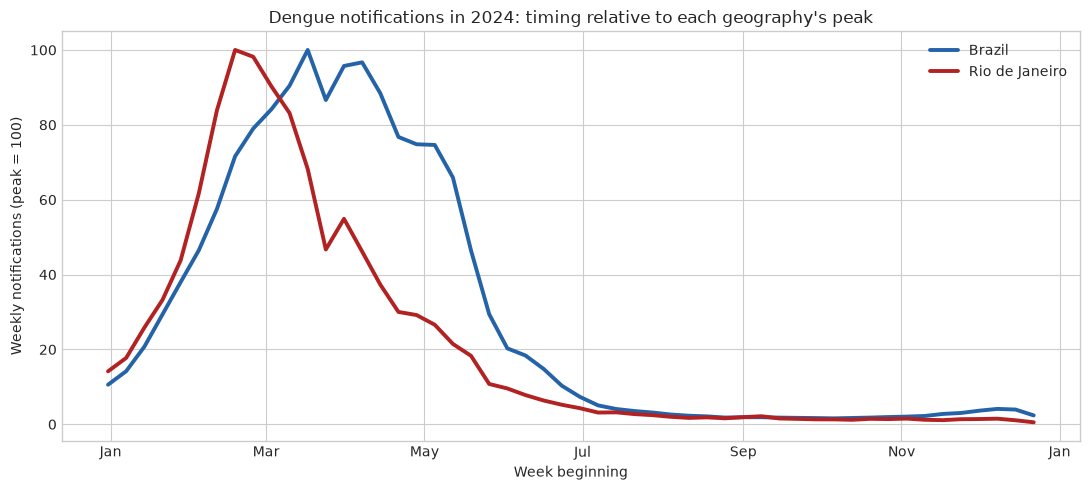

In [4]:
data_2024 = analysis.query('year == 2024').copy()
data_2024['peak_index'] = data_2024.groupby('geography')['sinan_notified_cases'].transform(lambda x: 100 * x / x.max())

fig, ax = plt.subplots(figsize=(11, 5))
for geography, group in data_2024.groupby('geography'):
    ax.plot(group['date'], group['peak_index'], lw=2.8, color=COLORS[geography], label=geography)
ax.set(title="Dengue notifications in 2024: timing relative to each geography's peak",
       xlabel='Week beginning', ylabel='Weekly notifications (peak = 100)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Step 4 — Show the absolute weekly counts

After establishing timing, show absolute counts in separate panels. Separate y-axes avoid making Rio appear flat beside the national total while preserving the actual number of notifications in each geography.

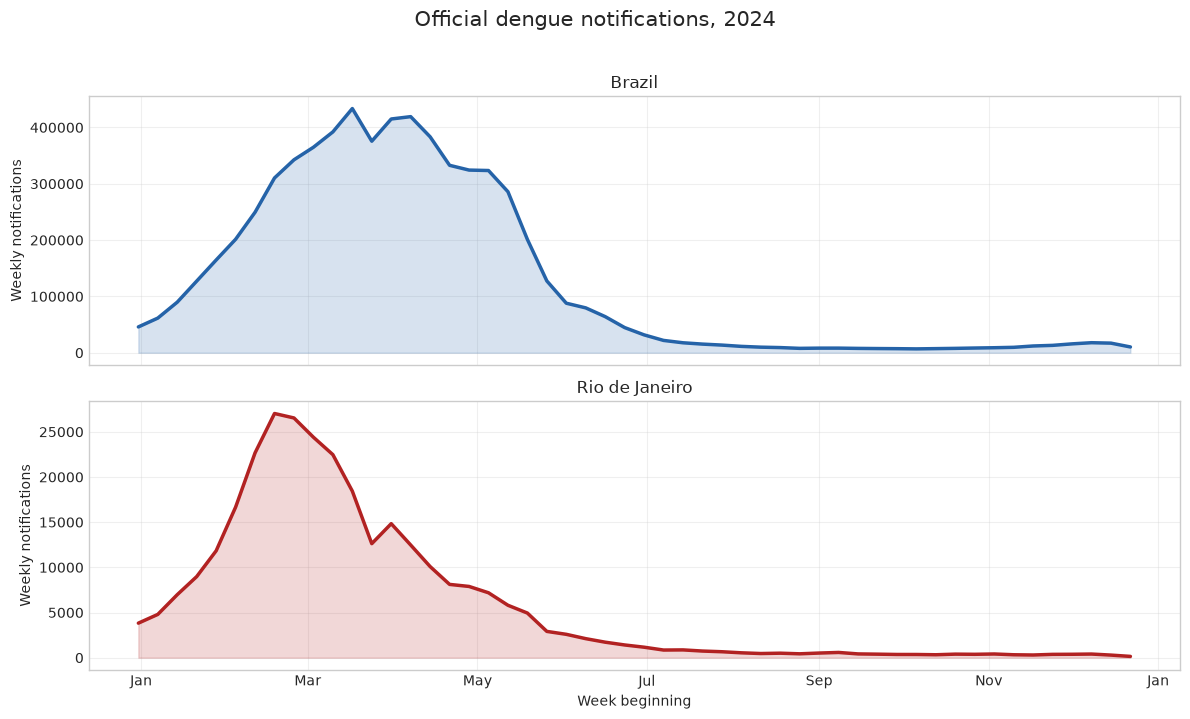

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, geography in zip(axes, ['Brazil', 'Rio de Janeiro']):
    group = data_2024.query('geography == @geography')
    ax.fill_between(group['date'], group['sinan_notified_cases'], color=COLORS[geography], alpha=0.18)
    ax.plot(group['date'], group['sinan_notified_cases'], color=COLORS[geography], lw=2.5)
    ax.set(title=geography, ylabel='Weekly notifications')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Week beginning')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.suptitle('Official dengue notifications, 2024', y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

## Step 5 — Compare seasons within each geography

This view answers a different question: how did the 2025 seasonal profile compare with 2024 within the same geography? Calendar position is used on the x-axis, and each year is indexed to its own peak. Do not interpret this as an incidence rate; denominators are not included in these files.

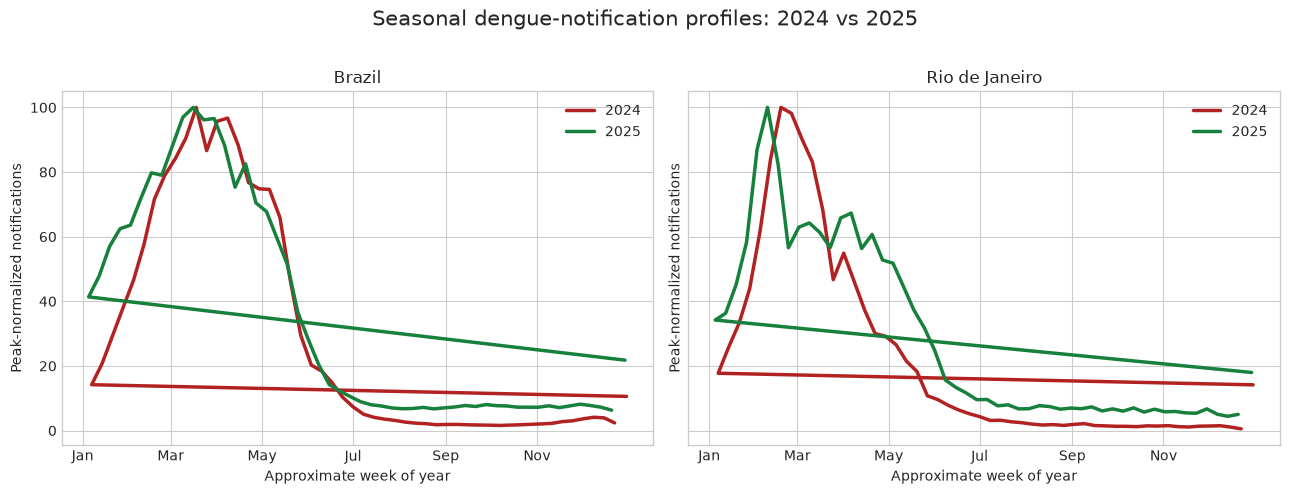

In [6]:
seasonal = analysis.copy()
seasonal['month_day'] = seasonal['date'].dt.strftime('%m-%d')
seasonal['peak_index'] = seasonal.groupby(['geography', 'year'])['sinan_notified_cases'].transform(lambda x: 100 * x / x.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, geography in zip(axes, ['Brazil', 'Rio de Janeiro']):
    for year, group in seasonal.query('geography == @geography').groupby('year'):
        ax.plot(group['date'].dt.dayofyear, group['peak_index'], lw=2.5, color=COLORS[str(year)], label=str(year))
    ax.set(title=geography, xlabel='Approximate week of year', ylabel='Peak-normalized notifications')
    ax.set_xticks([1, 60, 121, 182, 244, 305])
    ax.set_xticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'])
    ax.legend(frameon=False)
fig.suptitle('Seasonal dengue-notification profiles: 2024 vs 2025', y=1.02, fontsize=15)
fig.tight_layout()
plt.show()

## Step 6 — Summarize the descriptive evidence

A compact table gives you numbers to cite while presenting. Totals exclude the boundary weeks identified above. The peak week is the week beginning date with the largest number of notifications.

In [7]:
summary = (analysis.groupby(['geography', 'year'])
           .agg(total_notifications=('sinan_notified_cases', 'sum'),
                peak_week=('date', lambda x: x.loc[x.index[analysis.loc[x.index, 'sinan_notified_cases'].argmax()]]),
                peak_notifications=('sinan_notified_cases', 'max'))
           .reset_index())
summary['peak_week'] = summary['peak_week'].dt.strftime('%Y-%m-%d')
summary

,geography,year,total_notifications,peak_week,peak_notifications
0,Brazil,2024,6559686,2024-03-17,433513
1,Brazil,2025,1629233,2025-03-16,90265
2,Rio de Janeiro,2024,301812,2024-02-18,27026
3,Rio de Janeiro,2025,29351,2025-02-09,1997


## Suggested closing script

- The figures describe notifications by **symptom-onset week**, not a causal relationship or a final confirmed-case count.
- Brazil and Rio show a pronounced early-year dengue wave in the archived data; peak-normalized plots are useful for comparing timing across unequal population sizes.
- Use the absolute-count panels for burden and the indexed panels for timing/shape—do not mix the two interpretations.
- The endpoint weeks are handled conservatively because calendar-year extracts do not contain a complete cross-year week.
- A next analytic step would require population denominators for rates, case-status fields for confirmed cases, or a pre-specified nowcasting design. Those additions are intentionally outside this DATASUS-only descriptive workflow.

**Provenance.** Brazil: `wikipedia/brazil_sinan_dengue_2024_weekly.csv` and `...2025...`; Rio: `rj_trends/rio_dengue_trends_vs_sinan_2024_weekly.csv` and `rio_dengue_sinan_2025_weekly.csv`. These archived series were derived from Brazilian Ministry of Health Open Data SUS / SINAN dengue line lists.

## Part II — Online attention signals and nowcasts

The next figures answer a separate question from the descriptive DATASUS analysis: can contemporaneous online attention approximate the same week's SINAN notifications?

This is a **nowcast**, not an advance forecast. Google searches occur during the week of interest, and monthly Wikipedia totals are only complete after month-end. Predictors are therefore not treated as information available far in advance.

### Step 7 — Inspect the attention signals before modeling

Compare timing rather than raw scale. Google Trends is a normalized 0–100 index; Portuguese Wikipedia is monthly pageviews. SINAN notifications are also indexed to their own maxima. The Brazil panel uses the national search term and Portuguese Wikipedia; the Rio panel uses Rio search terms and the same Brazil-oriented Portuguese Wikipedia proxy.

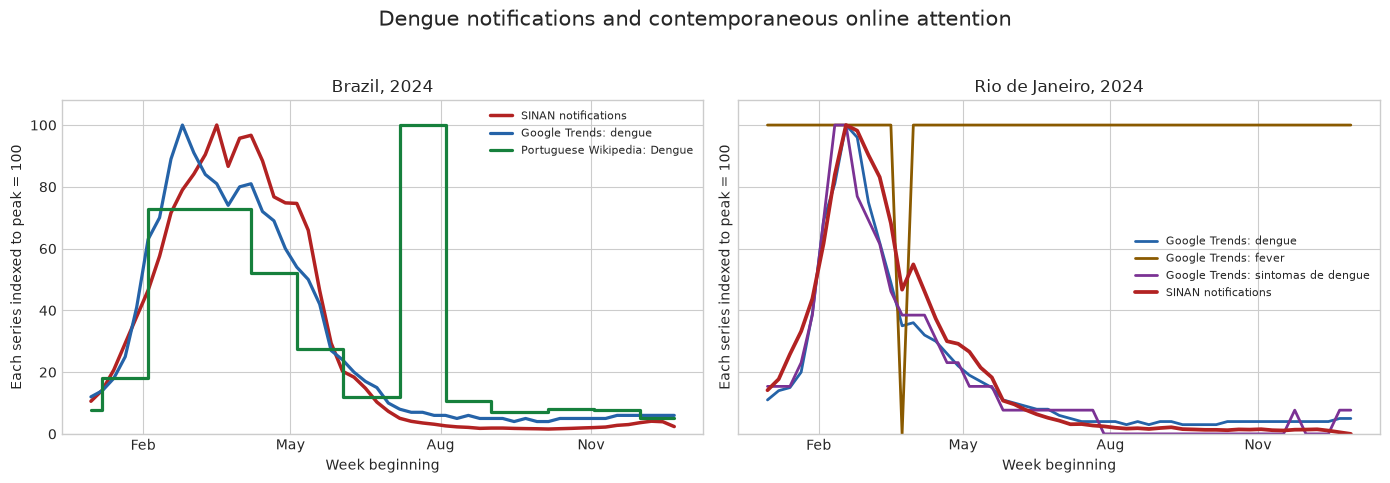

In [8]:
from IPython.display import Image, display

wiki_monthly = pd.read_csv(BRAZIL_DIR / 'brazil_wikipedia_pt_2023_2025_monthly.csv', parse_dates=['date'])
brazil_trends_2024 = pd.read_csv(BRAZIL_DIR / 'brazil_google_trends_dengue_2024_weekly.csv', parse_dates=['date'])
brazil_cases_2024 = pd.read_csv(BRAZIL_DIR / 'brazil_sinan_dengue_2024_weekly.csv', parse_dates=['date'])
rio_signal_2024 = pd.read_csv(RIO_DIR / 'rio_dengue_trends_vs_sinan_2024_weekly.csv', parse_dates=['date'])

brazil_signals = brazil_cases_2024.merge(brazil_trends_2024, on='date')
brazil_signals = pd.merge_asof(brazil_signals.sort_values('date'), wiki_monthly.sort_values('date'), on='date', direction='backward')
brazil_signals = brazil_signals.query("date < '2024-12-29'").copy()

def peak_index(values):
    return 100 * values / values.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
axes[0].plot(brazil_signals['date'], peak_index(brazil_signals['sinan_notified_cases']), color='#b22222', lw=2.5, label='SINAN notifications')
axes[0].plot(brazil_signals['date'], peak_index(brazil_signals['dengue']), color='#2563a8', lw=2.3, label='Google Trends: dengue')
axes[0].step(brazil_signals['date'], peak_index(brazil_signals['dengue_pt']), where='post', color='#16803c', lw=2.3, label='Portuguese Wikipedia: Dengue')
axes[0].set_title('Brazil, 2024')
axes[0].legend(frameon=False, fontsize=8)

for column, label, color in [('dengue', 'Google Trends: dengue', '#2563a8'), ('fever', 'Google Trends: fever', '#8a5a00'), ('sintomas_de_dengue', 'Google Trends: sintomas de dengue', '#7b3294')]:
    axes[1].plot(rio_signal_2024['date'], peak_index(rio_signal_2024[column]), lw=2, label=label, color=color)
axes[1].plot(rio_signal_2024['date'], peak_index(rio_signal_2024['sinan_notified_cases']), color='#b22222', lw=2.7, label='SINAN notifications')
axes[1].set_title('Rio de Janeiro, 2024')
axes[1].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.set(xlabel='Week beginning', ylabel='Each series indexed to peak = 100', ylim=(0, 108))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.suptitle('Dengue notifications and contemporaneous online attention', y=1.04, fontsize=15)
fig.tight_layout()
plt.show()

### Step 8 — Specify the retrospective model comparison

| Geography | Fixed model | Dynamic model | Predictors |
|---|---|---|---|
| Brazil | Fit on 2024 only, then held fixed in 2025 | Refit weekly on the previous 52 observed weeks | Same-week Brazil Google Trends dengue + monthly Portuguese Wikipedia Dengue pageviews |
| Rio | Fit on 2024 only, then held fixed in 2025 | Refit weekly on the previous 52 observed weeks | Same-week Rio Google Trends (dengue, fever, sintomas de dengue) + the same monthly Portuguese Wikipedia proxy |

The dynamic model can use notifications from earlier 2025 weeks, but never the current week's outcome. Both analyses exclude the partial week beginning 2025-12-28 from scoring.

### Step 9 — Evaluate the Brazil nowcasts in 2025

The fixed model is the strict year-ahead test: its coefficients come only from 2024. The dynamic model is operationally different: it adapts to recent observed notifications. Compare trajectories first, then use MAE, RMSE, and correlation as descriptive accuracy summaries.

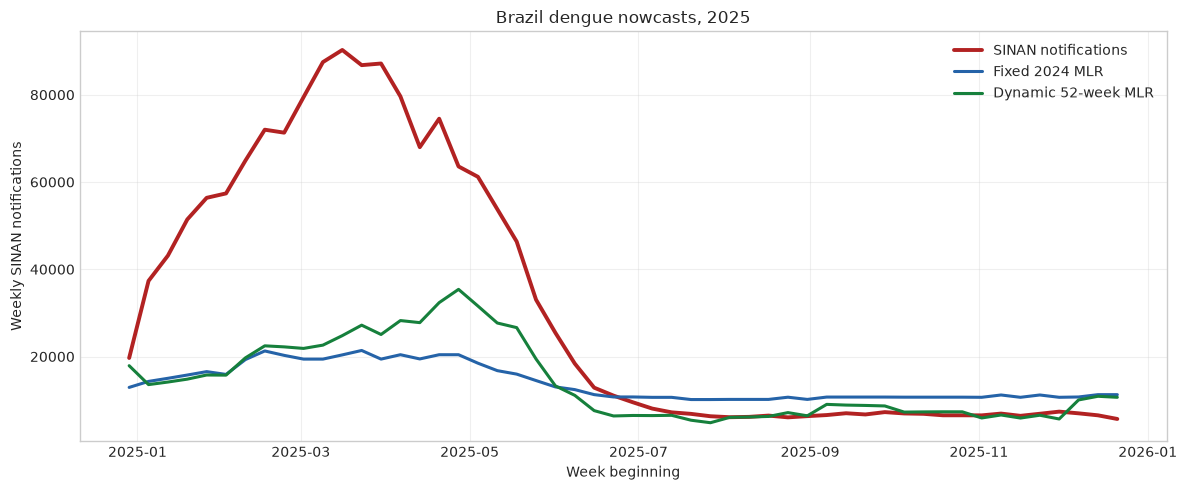

,model,mae,rmse,pearson_r,predicted_total
0,Fixed 2024 MLR,21294.0,31286.0,0.98,721956.0
1,Dynamic 52-week MLR,18131.0,28272.0,0.89,733816.0


In [9]:
brazil_pred = pd.read_csv(BRAZIL_DIR / 'brazil_dengue_2025_mlr_predictions.csv', parse_dates=['date'])
brazil_metrics = pd.read_csv(BRAZIL_DIR / 'brazil_dengue_2025_mlr_metrics.csv')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(brazil_pred['date'], brazil_pred['sinan_notified_cases'], color='#b22222', lw=2.8, label='SINAN notifications')
ax.plot(brazil_pred['date'], brazil_pred['fixed_2024_mlr_prediction'], color='#2563a8', lw=2.2, label='Fixed 2024 MLR')
ax.plot(brazil_pred['date'], brazil_pred['dynamic_52_week_mlr_prediction'], color='#16803c', lw=2.2, label='Dynamic 52-week MLR')
ax.set(title='Brazil dengue nowcasts, 2025', xlabel='Week beginning', ylabel='Weekly SINAN notifications')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

display(brazil_metrics.round({'mae': 0, 'rmse': 0, 'pearson_r': 2, 'predicted_total': 0}))

### Step 10 — Evaluate the Rio nowcasts in 2025

For Rio, retain the original Google-Trends-only model as a baseline, then compare it with Wikipedia-enhanced fixed and dynamic models. Keeping that baseline prevents us from attributing an apparent improvement to Wikipedia without a matched comparison.

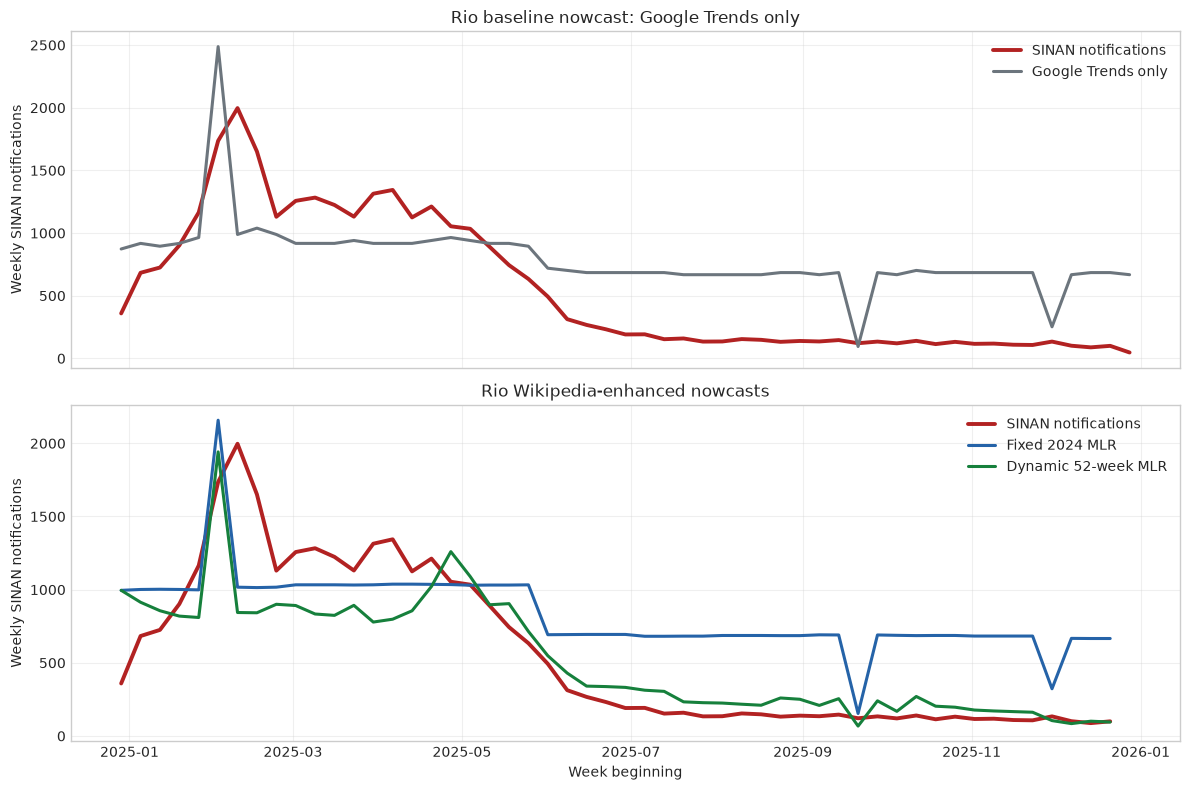

,model,mae,rmse,pearson_r,predicted_total
0,Fixed 2024 MLR,404.0,454.0,0.78,43295.0
1,Dynamic 52-week MLR,186.0,285.0,0.86,27586.0


In [10]:
rio_google_only = pd.read_csv(RIO_DIR / 'rio_dengue_2025_nowcast_predictions.csv', parse_dates=['date'])
rio_pred = pd.read_csv(RIO_DIR / 'rio_dengue_2025_mlr_dynamic_predictions.csv', parse_dates=['date'])
rio_metrics = pd.read_csv(RIO_DIR / 'rio_dengue_2025_mlr_dynamic_metrics.csv')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(rio_google_only['date'], rio_google_only['sinan_notified_cases'], color='#b22222', lw=2.8, label='SINAN notifications')
axes[0].plot(rio_google_only['date'], rio_google_only['predicted_notified_cases'], color='#6c757d', lw=2.2, label='Google Trends only')
axes[0].set(title='Rio baseline nowcast: Google Trends only', ylabel='Weekly SINAN notifications')
axes[0].legend(frameon=False)

axes[1].plot(rio_pred['date'], rio_pred['sinan_notified_cases'], color='#b22222', lw=2.8, label='SINAN notifications')
axes[1].plot(rio_pred['date'], rio_pred['fixed_mlr_prediction'], color='#2563a8', lw=2.2, label='Fixed 2024 MLR')
axes[1].plot(rio_pred['date'], rio_pred['dynamic_52_week_prediction'], color='#16803c', lw=2.2, label='Dynamic 52-week MLR')
axes[1].set(title='Rio Wikipedia-enhanced nowcasts', xlabel='Week beginning', ylabel='Weekly SINAN notifications')
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

display(rio_metrics.round({'mae': 0, 'rmse': 0, 'pearson_r': 2, 'predicted_total': 0}))

### Step 11 — Isolate the value of Wikipedia in Rio

This is the matched evaluation: Google-Trends-only and Trends-plus-Wikipedia versions are scored on the same 52 complete 2025 weeks. Lower MAE/RMSE and higher correlation indicate a closer retrospective match to the SINAN notifications. The comparison is associational; it does not establish that pageviews cause changes in notifications.

,model,version,mae,rmse,pearson_r
0,Fixed 2024 MLR,Google Trends only,392.0,438.0,0.68
1,Fixed 2024 MLR,Trends + Wikipedia,404.0,454.0,0.78
2,Dynamic 52-week MLR,Google Trends only,226.0,360.0,0.75
3,Dynamic 52-week MLR,Trends + Wikipedia,186.0,285.0,0.86


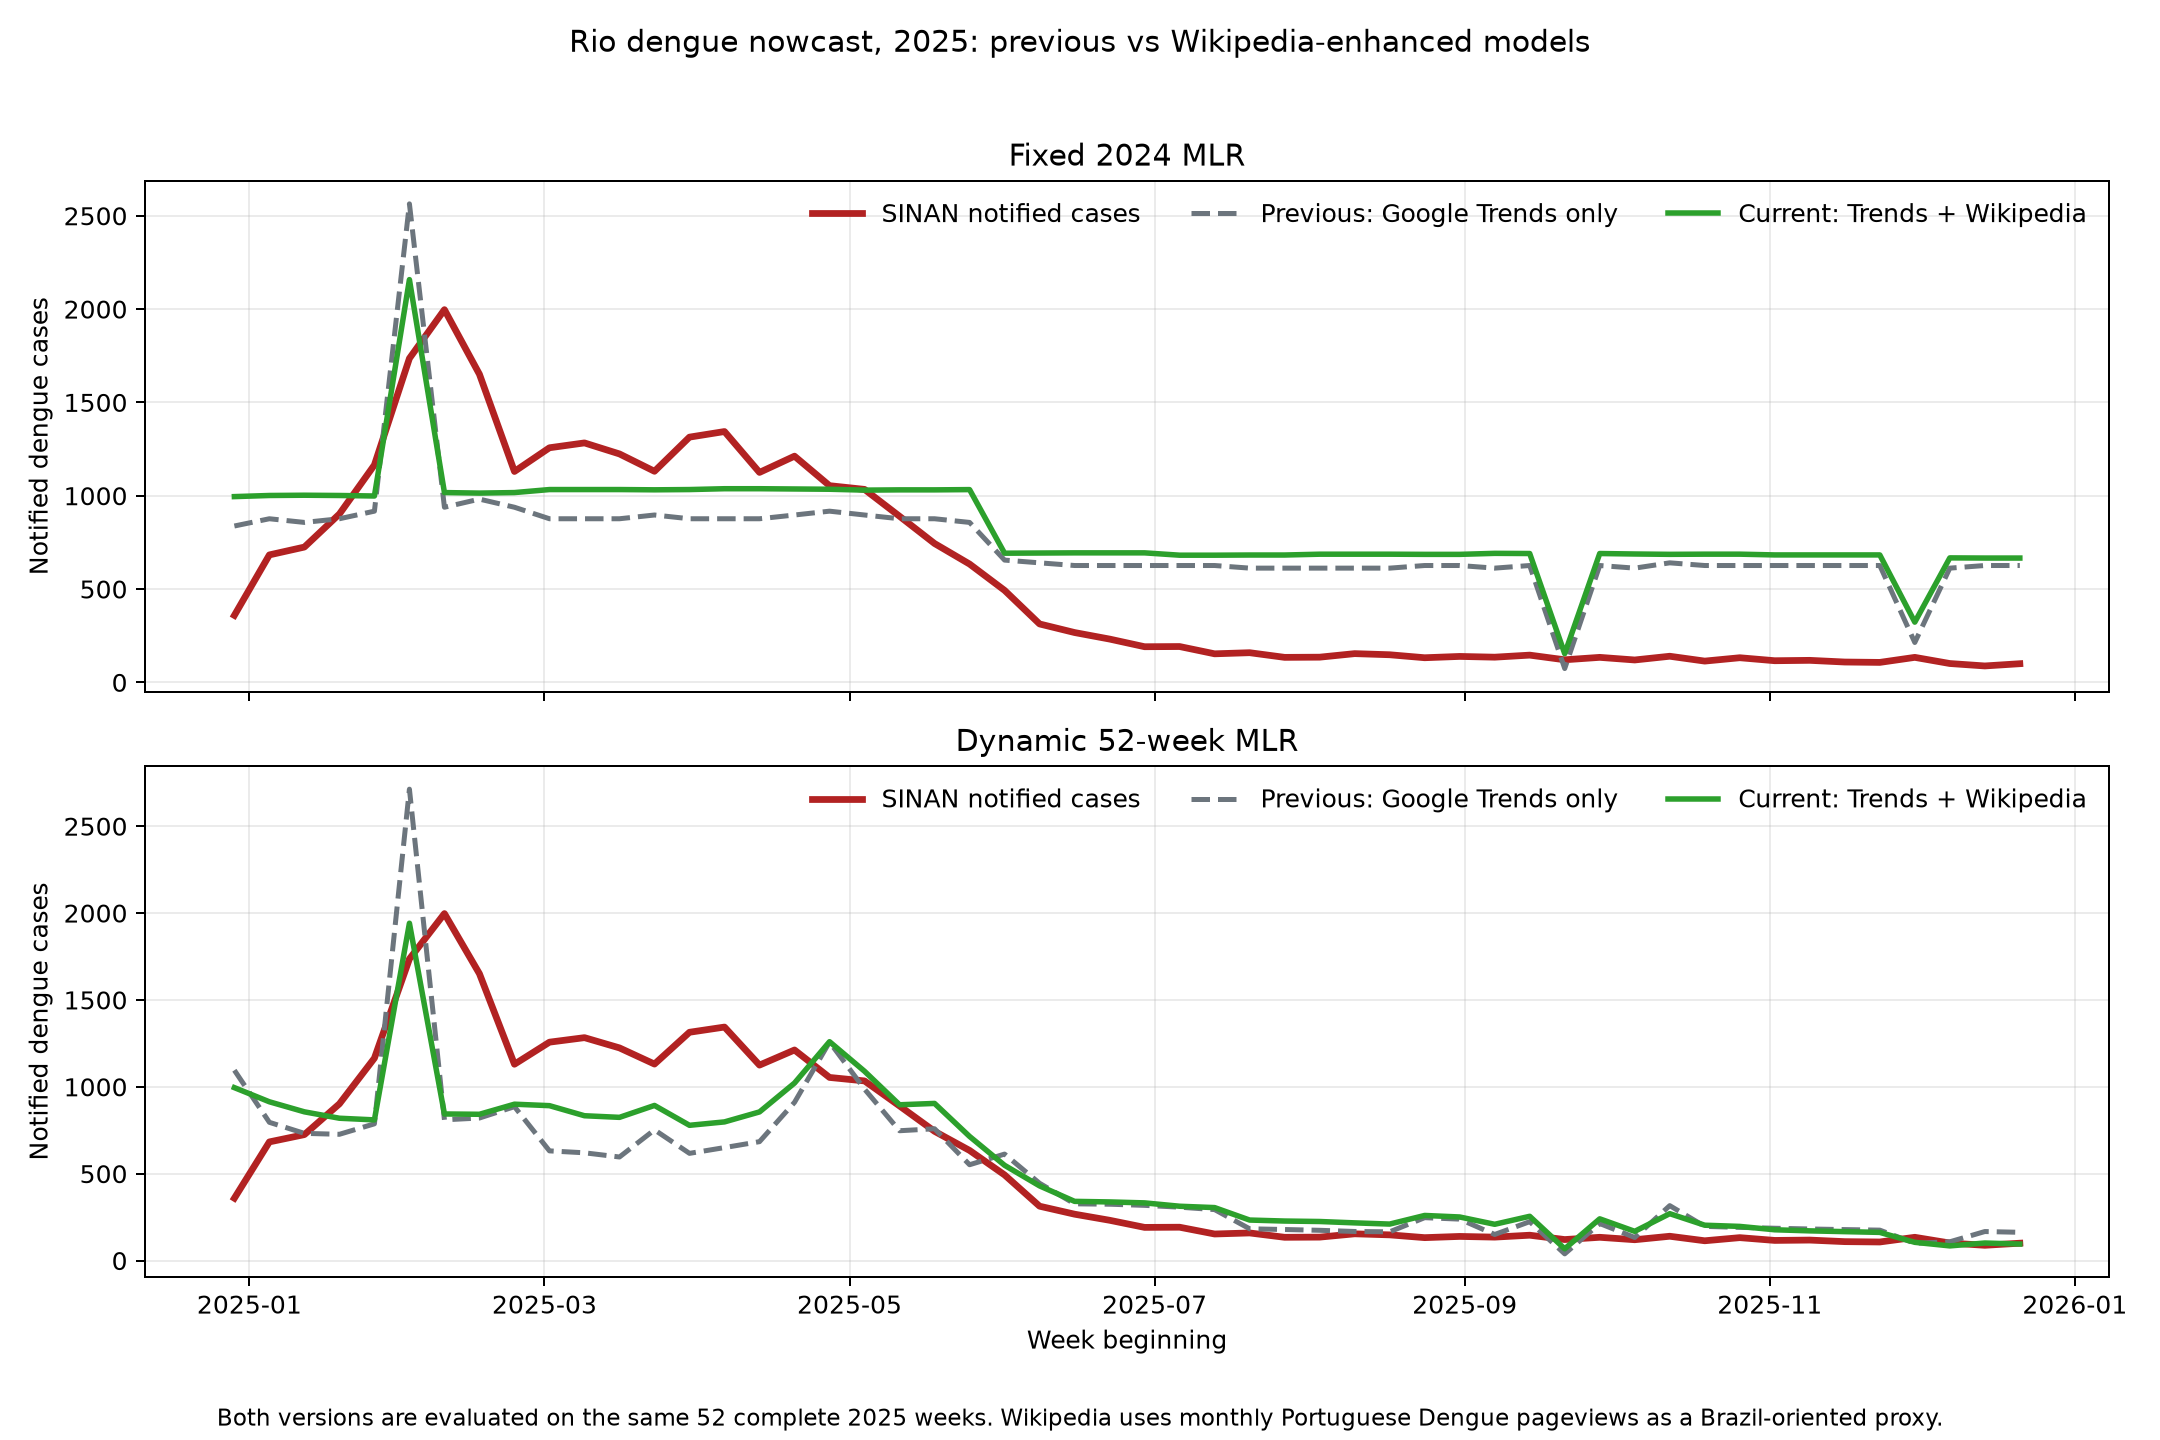

In [11]:
rio_version_metrics = pd.read_csv(RIO_DIR / 'rio_dengue_2025_nowcast_version_comparison_metrics.csv')
display(rio_version_metrics.round({'mae': 0, 'rmse': 0, 'pearson_r': 2}))

display(Image(filename=str(RIO_DIR / 'rio_dengue_2025_nowcast_version_comparison.png')))

## Final presentation takeaways

1. **Start with DATASUS/SINAN.** The descriptive plots establish seasonal notification patterns before any model.
2. **Separate timing from burden.** Peak-normalized figures compare shapes; absolute-count panels convey notification volume.
3. **Name the prediction target precisely.** Models estimate same-week notified records by symptom-onset week, not final confirmed or future cases.
4. **Keep comparisons fair.** Fixed 2024 models test temporal transfer; rolling 52-week models adapt using prior observed weeks.
5. **Treat Wikipedia as a Brazil-oriented attention proxy.** It is monthly, not Rio-specific, and its apparent Rio value is assessed only through the matched 2025 comparison.

**Sources.** Outcomes are the archived DATASUS/SINAN weekly series. Predictors and model outputs are the saved Google Trends and Portuguese Wikipedia extracts in rj_trends and wikipedia. The final week crossing into 2026 is excluded from model scores.

# Part III — Does notification-system activity track disease-specific public attention?

## Hypothesis

The first formal notification of an arboviral illness in SINAN may be correlated with disease-specific information seeking. To examine that hypothesis, we compare weekly Brazil-wide notification dates for **dengue**, **chikungunya**, and **Zika** with Portuguese Google searches and Portuguese Wikipedia pageviews for each disease.

This is an observational salience analysis. It asks whether signals move together; it does not identify the cause of notifications or prove that online attention affects diagnosis.

### Step 12 — Align the outcome with the hypothesis

This section changes the outcome definition used in Parts I and II. The outcome is now **DT_NOTIFIC**, the date on which a record is notified in SINAN, aggregated to Sunday–Saturday weeks. That is the appropriate timestamp for a question about initial information-system registration.

| Disease | Official SINAN source | Portuguese Google term | Portuguese Wikipedia article |
|---|---|---|---|
| Dengue | Open Data SUS dengue line list | dengue | Dengue |
| Chikungunya | Open Data SUS chikungunya line list | chikungunya | Chicungunha |
| Zika | Open Data SUS Zika-virus line list | zika | Febre zika |

The 2024 and 2025 annual extracts include boundary weeks. For fair evaluation, the model trains on 2024 surveillance weeks beginning 2023-12-31 through 2024-12-22 and evaluates the 52 complete 2025 weeks beginning 2024-12-29 through 2025-12-21.

In [12]:
import numpy as np

PART3_DIR = ROOT / 'part3_arboviruses'
arbovirus = pd.read_csv(PART3_DIR / 'brazil_arbovirus_notification_attention_2024_2025_weekly.csv', parse_dates=['date'])
arbovirus['analysis_year'] = np.where(arbovirus['date'].between('2023-12-31', '2024-12-22'), 2024,
                                      np.where(arbovirus['date'].between('2024-12-29', '2025-12-21'), 2025, np.nan))
arbovirus_analysis = arbovirus.dropna(subset=['analysis_year']).copy()
arbovirus_analysis['analysis_year'] = arbovirus_analysis['analysis_year'].astype(int)

quality = (arbovirus_analysis.groupby(['disease', 'analysis_year'])
           .agg(weeks=('date', 'size'),
                first_week=('date', 'min'),
                last_week=('date', 'max'),
                notifications=('sinan_notifications', 'sum'),
                missing_signals=('google_trends', lambda x: x.isna().sum()))
           .reset_index())
quality

,disease,analysis_year,weeks,first_week,last_week,notifications,missing_signals
0,chikungunya,2024,52,2023-12-31,2024-12-22,425040,0
1,chikungunya,2025,53,2024-12-29,2025-12-21,250856,0
2,dengue,2024,52,2023-12-31,2024-12-22,6563899,0
3,dengue,2025,53,2024-12-29,2025-12-21,1631977,0
4,zika,2024,52,2023-12-31,2024-12-22,43155,0
5,zika,2025,53,2024-12-29,2025-12-21,25723,0


### Step 13 — Inspect disease-specific notification and attention patterns

All three lines in each panel are scaled to that disease's own peak. This allows a within-disease timing comparison across different units: SINAN notifications, Google Trends interest, and monthly Wikipedia pageviews. It does **not** compare absolute disease burden across diseases.

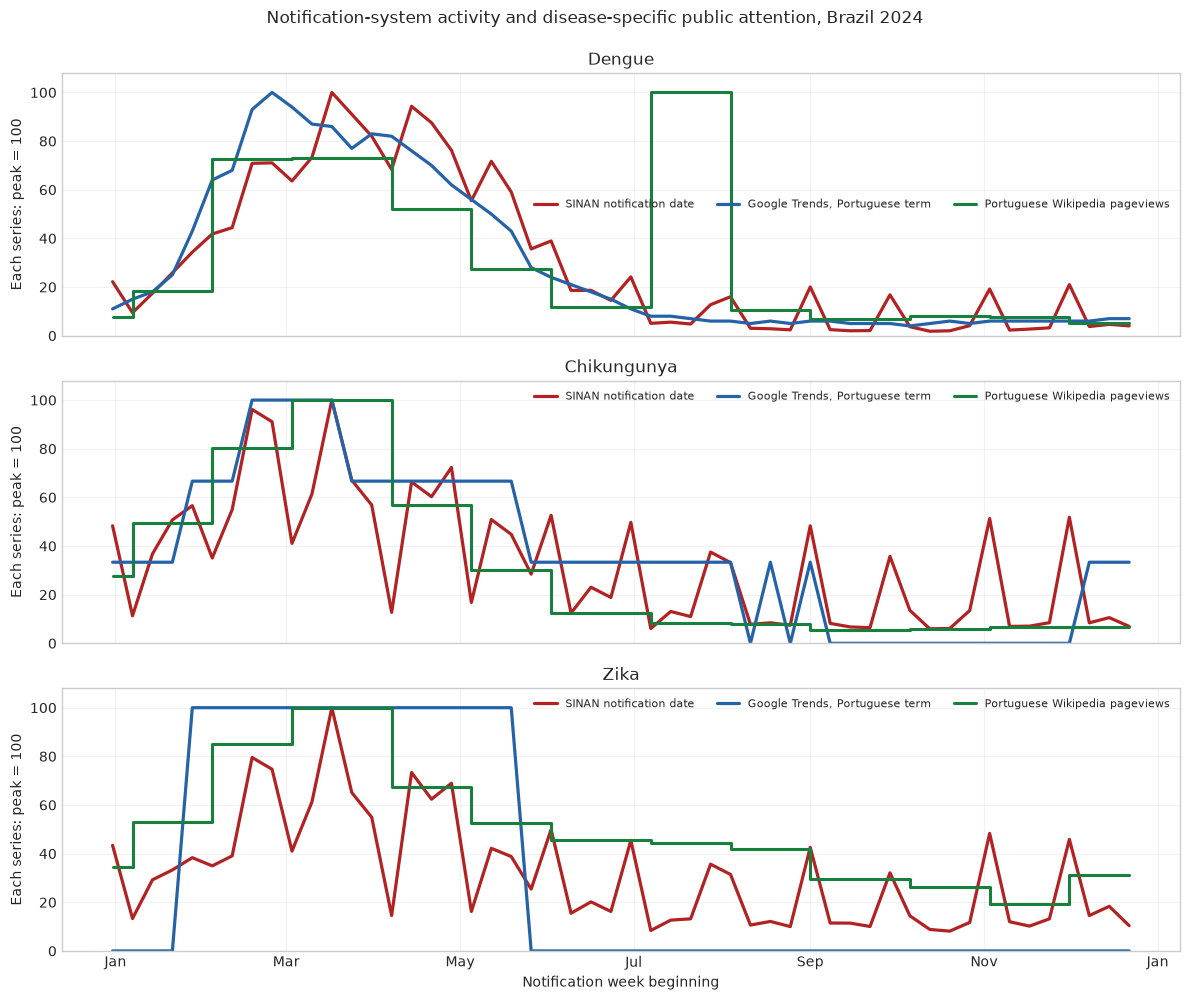

In [13]:
def index_to_peak(values):
    return 100 * values / values.max()

signal_labels = {
    'sinan_notifications': ('SINAN notification date', '#b22222'),
    'google_trends': ('Google Trends, Portuguese term', '#2563a8'),
    'wikipedia_pageviews': ('Portuguese Wikipedia pageviews', '#16803c'),
}
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, disease in zip(axes, ['dengue', 'chikungunya', 'zika']):
    group = arbovirus_analysis.query("analysis_year == 2024 and disease == @disease")
    for variable, (label, color) in signal_labels.items():
        draw = ax.step if variable == 'wikipedia_pageviews' else ax.plot
        if variable == 'wikipedia_pageviews':
            draw(group['date'], index_to_peak(group[variable]), where='post', color=color, lw=2.2, label=label)
        else:
            draw(group['date'], index_to_peak(group[variable]), color=color, lw=2.3, label=label)
    ax.set(title=disease.capitalize(), ylabel='Each series: peak = 100', ylim=(0, 108))
    ax.legend(frameon=False, ncol=3, fontsize=8)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Notification week beginning')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.suptitle('Notification-system activity and disease-specific public attention, Brazil 2024', y=0.995)
fig.tight_layout()
plt.show()

### Step 14 — Quantify the association, rather than relying only on visual alignment

Pearson correlation captures linear co-movement; Spearman correlation captures agreement in weekly rank/order. Each correlation is within disease and surveillance year. These values are descriptive because outbreaks, reporting practices, media coverage, and information seeking can all be common causes.

,year,disease,signal,pearson_r,spearman_r
0,2024,chikungunya,google_trends,0.71,0.69
1,2024,chikungunya,wikipedia_pageviews,0.71,0.70
2,2024,dengue,google_trends,0.93,0.88
3,2024,dengue,wikipedia_pageviews,0.52,0.63
4,2024,zika,google_trends,0.66,0.63
5,2024,zika,wikipedia_pageviews,0.69,0.65
6,2025,chikungunya,google_trends,0.67,0.69
7,2025,chikungunya,wikipedia_pageviews,-0.04,0.27
8,2025,dengue,google_trends,0.87,0.76
9,2025,dengue,wikipedia_pageviews,0.76,0.66


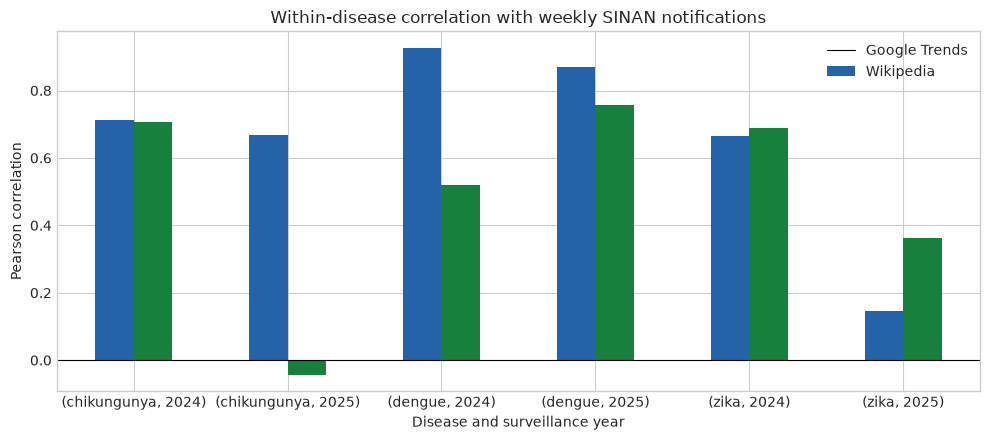

In [14]:
correlations = pd.read_csv(PART3_DIR / 'brazil_arbovirus_attention_correlations.csv')
display(correlations.round({'pearson_r': 2, 'spearman_r': 2}))

plot_data = correlations.pivot(index=['disease', 'year'], columns='signal', values='pearson_r')
ax = plot_data.plot.bar(figsize=(10, 4.5), color=['#2563a8', '#16803c'])
ax.axhline(0, color='black', lw=0.8)
ax.set(title='Within-disease correlation with weekly SINAN notifications',
       xlabel='Disease and surveillance year', ylabel='Pearson correlation')
ax.legend(['Google Trends', 'Wikipedia'], frameon=False)
ax.tick_params(axis='x', rotation=0)
ax.figure.tight_layout()
plt.show()

### Step 15 — Compare fixed and dynamic seasonal nowcasts

Both models are pooled ridge regressions predicting log weekly notifications from the disease-specific Portuguese Google Trends value, Portuguese Wikipedia pageviews, disease indicators, and cyclic week-of-year terms. Disease-specific sine/cosine interactions allow each disease to have a different seasonal curve. Ridge regularization stabilizes correlated attention predictors.

- **Fixed 2024 attention + season:** fit using 2024 surveillance weeks only, then held fixed for 2025. This is the temporal-transfer test.
- **Dynamic 52-week attention + season:** before each 2025 prediction, refit using only the preceding 52 complete notification weeks across all diseases. It can use earlier 2025 notifications, but never the current week's outcome.

The dynamic result is a retrospective nowcast comparison, not an advance forecast or causal effect estimate.

,model,disease,mae,rmse,pearson_r,observed_total,predicted_total
0,Fixed 2024 attention + season,chikungunya,2138.0,2660.0,0.92,250856,364192.0
1,Fixed 2024 attention + season,dengue,42839.0,55919.0,0.86,1631977,3773207.0
2,Fixed 2024 attention + season,zika,236.0,279.0,0.89,25723,38228.0
3,Fixed 2024 attention + season,pooled,15071.0,32322.0,0.92,1908556,4175626.0
4,Dynamic 52-week attention + season,chikungunya,1110.0,1636.0,0.88,250856,280614.0
5,Dynamic 52-week attention + season,dengue,12097.0,15889.0,0.80,1631977,1685748.0
6,Dynamic 52-week attention + season,zika,116.0,169.0,0.87,25723,30922.0
7,Dynamic 52-week attention + season,pooled,4441.0,9222.0,0.89,1908556,1997284.0


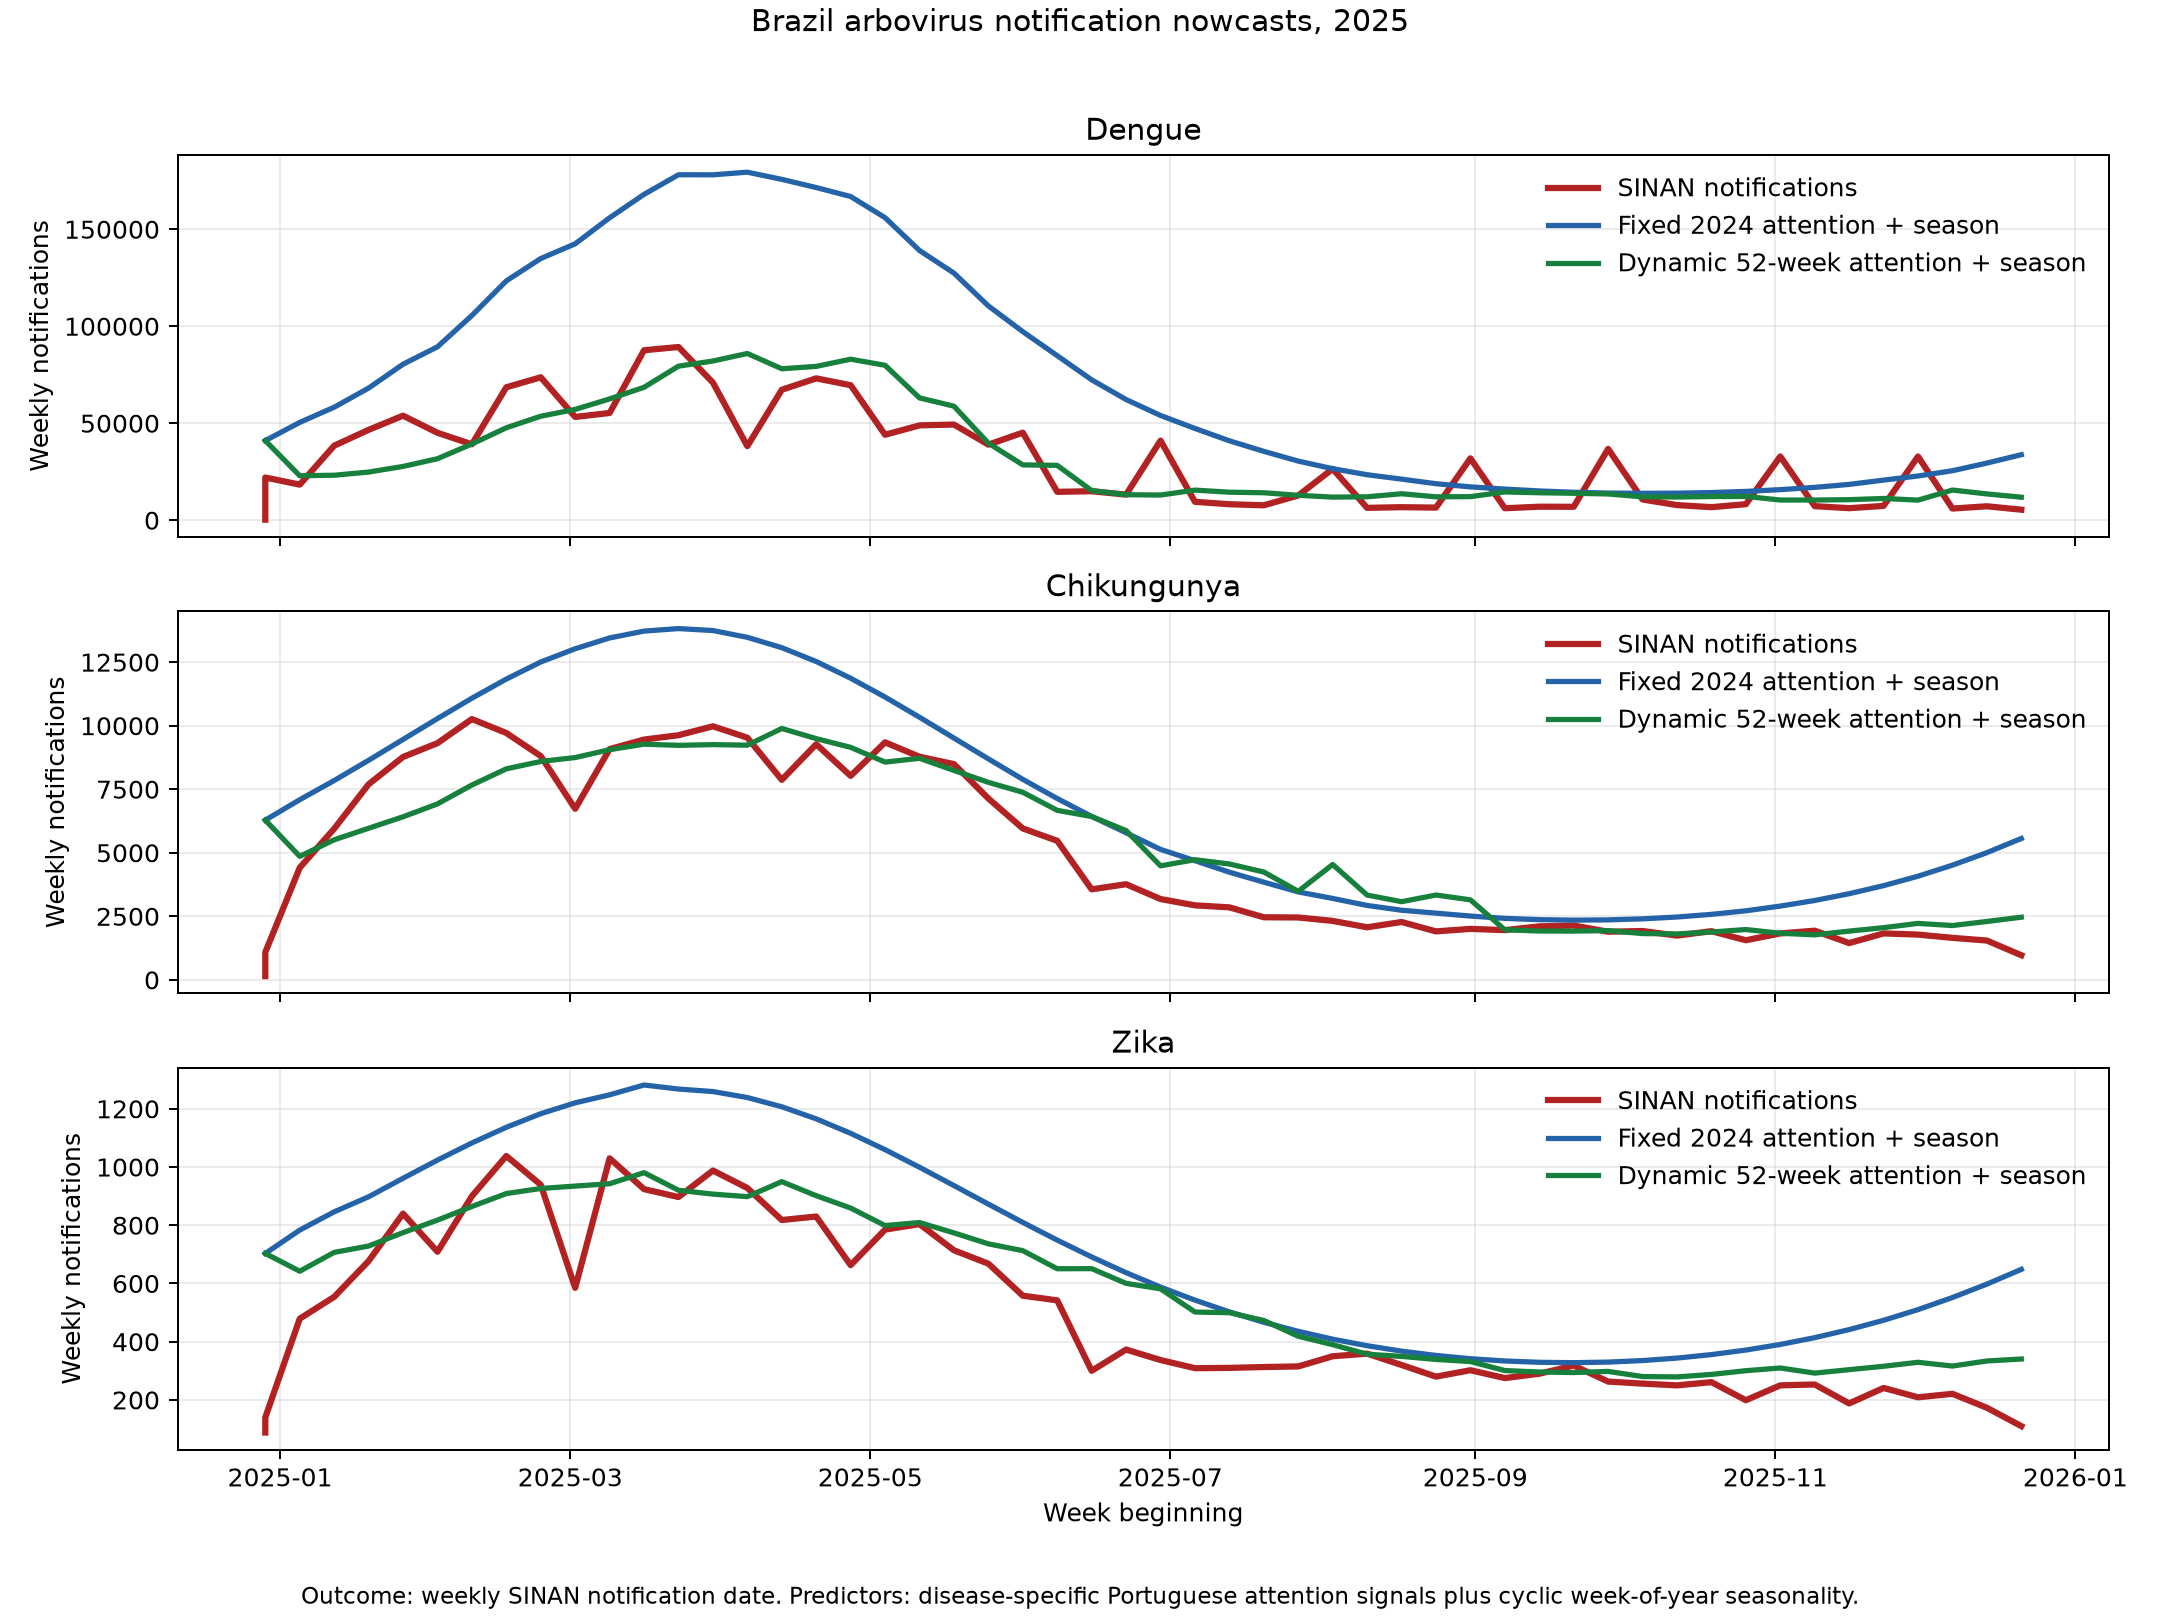

In [15]:
arbovirus_metrics = pd.read_csv(PART3_DIR / 'brazil_arbovirus_2025_attention_metrics.csv')
display(arbovirus_metrics.round({'mae': 0, 'rmse': 0, 'pearson_r': 2, 'observed_total': 0, 'predicted_total': 0}))
display(Image(filename=str(PART3_DIR / 'brazil_arbovirus_2025_attention_predictions.png')))

## Part III interpretation and suggested presentation script

- **Use the word association.** The analysis finds that disease-specific online attention and weekly notification-system activity often co-vary, especially for dengue and chikungunya in these archived periods.
- **Zika is a useful contrast.** Its weaker 2025 correlations/model fit show that a named online signal is not automatically a reliable proxy for every low- or differently-salient disease.
- **Notification timing is not disease onset.** DT_NOTIFIC can reflect care seeking, clinical suspicion, laboratory/testing workflows, and reporting delays in addition to transmission.
- **Salience is disease-specific but not perfectly diagnostic-specific.** Search terms and articles can be used by the public, clinicians, media, and students; they do not identify who searched or why.
- **The model is a retrospective 2024-to-2025 check, not a causal or operational deployment claim.** A next step would pre-register lag structures, reporting-delay handling, and a prospective evaluation.

**Data provenance.** The outcome tables were downloaded from the official Brazilian Ministry of Health Open Data SUS / SINAN annual line lists for 2024 and 2025: dengue (CSV), chikungunya (CSV), and Zika virus (JSON). Portuguese Google Trends terms were retrieved together for Brazil over 2024–2025; Portuguese Wikipedia monthly pageviews use the disease-specific articles listed above.